<a href="https://colab.research.google.com/github/iqlore-collab/API-PROJECTS/blob/main/Weather_in_cities_GITHUB_COLAB_READY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather in German Cities

This notebook collects weather forecast data for selected German cities using the OpenWeather API.

It is designed to work in:

- Google Colab
- Jupyter Notebook
- GitHub preview

The original GUI-based city input was removed because `tkinter` does not work in Colab.

Instead, the notebook uses:
- a normal Python list of cities,
- secure API key input with `getpass`,
- error handling for failed API calls,
- clean pandas DataFrames,
- CSV export.


## 1. Setup

You need an OpenWeather API key.

Create one at OpenWeather and paste it when the notebook asks for it.

The key is not stored in the notebook.


In [7]:
import time
from getpass import getpass

import requests
import pandas as pd
import matplotlib.pyplot as plt


## 2. Configuration

Edit the city list below.

By default, the notebook queries major German cities.


In [9]:
API_KEY = getpass("Insert API: ")

CITIES = [
    "Berlin",
    "Hamburg",
    "Munich",
    "Cologne",
    "Frankfurt",
]

COUNTRY_CODE = "DE"
UNITS = "metric"
LANGUAGE = "en"


Insert API: ··········


## 3. Helper functions

These functions handle:
- geocoding city names to latitude/longitude,
- downloading 5-day forecast data,
- checking API errors.


In [10]:
def safe_get_json(url: str, params: dict | None = None, timeout: int = 20) -> dict | list | None:
    try:
        response = requests.get(url, params=params, timeout=timeout)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.HTTPError as error:
        print(f"HTTP error: {error}")
    except requests.exceptions.RequestException as error:
        print(f"Request error: {error}")
    except ValueError:
        print("Could not parse JSON response.")

    return None


def geocode_city(city: str, country_code: str, api_key: str) -> dict | None:
    url = "https://api.openweathermap.org/geo/1.0/direct"
    params = {
        "q": f"{city},{country_code}",
        "limit": 1,
        "appid": api_key,
    }

    data = safe_get_json(url, params=params)

    if not data:
        print(f"No geocoding result for: {city}")
        return None

    result = data[0]

    return {
        "city": city,
        "matched_name": result.get("name"),
        "country": result.get("country"),
        "lat": result.get("lat"),
        "lon": result.get("lon"),
    }


def get_forecast(lat: float, lon: float, api_key: str, units: str = "metric", lang: str = "en") -> dict | None:
    url = "https://api.openweathermap.org/data/2.5/forecast"
    params = {
        "lat": lat,
        "lon": lon,
        "appid": api_key,
        "units": units,
        "lang": lang,
    }

    return safe_get_json(url, params=params)


## 4. Geocode cities

The OpenWeather forecast API requires latitude and longitude, so first we convert city names into coordinates.


In [11]:
geo_rows = []

for city in CITIES:
    result = geocode_city(city, COUNTRY_CODE, API_KEY)

    if result is not None:
        geo_rows.append(result)

    time.sleep(0.2)

df_cities = pd.DataFrame(geo_rows)

df_cities


,city,matched_name,country,lat,lon
0,Berlin,Berlin,DE,52.510885,13.398937
1,Hamburg,Hamburg,DE,53.550341,10.000654
2,Munich,Munich,DE,48.137108,11.575382
3,Cologne,Cologne,DE,50.938361,6.959974
4,Frankfurt,Frankfurt,DE,50.110644,8.682092


## 5. Download forecasts

The OpenWeather 5-day forecast API returns weather data in 3-hour intervals.


In [12]:
forecast_rows = []

for _, row in df_cities.iterrows():
    forecast = get_forecast(
        lat=row["lat"],
        lon=row["lon"],
        api_key=API_KEY,
        units=UNITS,
        lang=LANGUAGE,
    )

    if forecast is None or "list" not in forecast:
        print(f"No forecast data for: {row['city']}")
        continue

    for item in forecast["list"]:
        forecast_rows.append({
            "city": row["city"],
            "datetime": item.get("dt_txt"),
            "temp": item["main"].get("temp"),
            "feels_like": item["main"].get("feels_like"),
            "temp_min": item["main"].get("temp_min"),
            "temp_max": item["main"].get("temp_max"),
            "humidity": item["main"].get("humidity"),
            "pressure": item["main"].get("pressure"),
            "wind_speed": item["wind"].get("speed"),
            "cloudiness": item["clouds"].get("all"),
            "description": item["weather"][0].get("description"),
        })

    time.sleep(0.2)

df_forecast = pd.DataFrame(forecast_rows)

df_forecast["datetime"] = pd.to_datetime(df_forecast["datetime"])

df_forecast.head()


,city,datetime,temp,feels_like,temp_min,temp_max,humidity,pressure,wind_speed,cloudiness,description
0,Berlin,2026-05-19 12:00:00,19.72,19.21,19.72,19.73,56,1018,2.98,20,light rain
1,Berlin,2026-05-19 15:00:00,20.37,19.77,20.37,21.67,50,1018,2.47,33,scattered clouds
2,Berlin,2026-05-19 18:00:00,19.56,18.88,19.48,19.56,50,1017,1.20,53,broken clouds
3,Berlin,2026-05-19 21:00:00,14.98,14.15,14.98,14.98,62,1019,1.58,70,broken clouds
4,Berlin,2026-05-20 00:00:00,9.12,9.12,9.12,9.12,67,1019,1.24,72,broken clouds


## 6. Current nearest forecast

The forecast API does not return true current weather.  
The table below uses the first forecast entry for each city, which is the nearest forecasted time.


In [13]:
df_current_like = (
    df_forecast
    .sort_values("datetime")
    .groupby("city", as_index=False)
    .first()
)

df_current_like


,city,datetime,temp,feels_like,temp_min,temp_max,humidity,pressure,wind_speed,cloudiness,description
0,Berlin,2026-05-19 12:00:00,19.72,19.21,19.72,19.73,56,1018,2.98,20,light rain
1,Cologne,2026-05-19 12:00:00,15.68,15.37,15.68,17.38,79,1017,3.60,75,light rain
2,Frankfurt,2026-05-19 12:00:00,18.45,17.81,18.09,18.45,56,1018,3.66,40,scattered clouds
3,Hamburg,2026-05-19 12:00:00,16.54,15.76,16.54,18.79,58,1017,2.62,40,light rain
4,Munich,2026-05-19 12:00:00,17.46,16.75,17.46,18.42,57,1018,1.76,49,scattered clouds


## 7. Daily forecast summary

This section aggregates the 3-hour forecast into daily city-level summaries.


In [14]:
df_forecast["date"] = df_forecast["datetime"].dt.date

df_daily = (
    df_forecast
    .groupby(["city", "date"], as_index=False)
    .agg(
        avg_temp=("temp", "mean"),
        min_temp=("temp_min", "min"),
        max_temp=("temp_max", "max"),
        avg_humidity=("humidity", "mean"),
        avg_wind_speed=("wind_speed", "mean"),
        avg_cloudiness=("cloudiness", "mean"),
    )
)

df_daily = df_daily.round(2)

df_daily.head(15)


,city,date,avg_temp,min_temp,max_temp,avg_humidity,avg_wind_speed,avg_cloudiness
0,Berlin,2026-05-19,18.66,14.98,21.67,54.50,2.06,44.00
1,Berlin,2026-05-20,13.97,9.12,17.04,77.50,2.69,90.00
2,Berlin,2026-05-21,15.08,10.24,19.11,76.50,3.60,41.50
3,Berlin,2026-05-22,16.34,11.93,20.52,74.38,2.93,72.25
4,Berlin,2026-05-23,19.86,13.39,25.37,67.88,2.36,35.88
5,Berlin,2026-05-24,18.22,16.31,21.17,82.25,3.70,78.00
6,Cologne,2026-05-19,15.19,14.02,17.38,84.25,2.99,87.50
7,Cologne,2026-05-20,14.20,11.67,17.11,87.00,3.77,80.25
8,Cologne,2026-05-21,15.61,9.82,21.08,76.12,1.89,79.75
9,Cologne,2026-05-22,19.00,11.90,25.38,66.88,1.25,28.00


## 8. Visualization

The plot below compares average forecasted temperature by city and day.


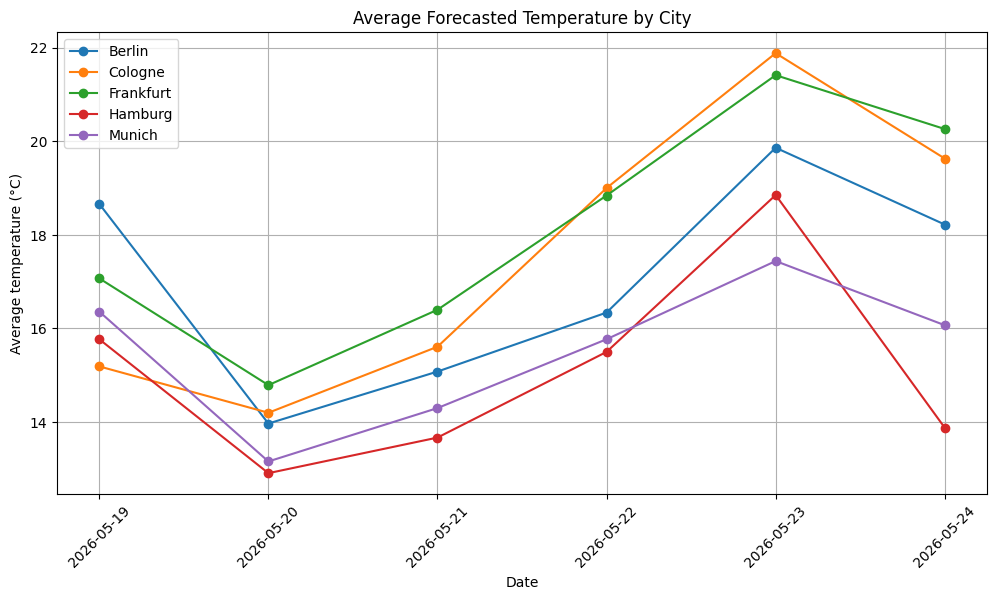

In [15]:
plt.figure(figsize=(12, 6))

for city in df_daily["city"].unique():
    city_data = df_daily[df_daily["city"] == city]
    plt.plot(city_data["date"], city_data["avg_temp"], marker="o", label=city)

plt.title("Average Forecasted Temperature by City")
plt.xlabel("Date")
plt.ylabel("Average temperature (°C)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


## 9. Export results

The notebook exports three CSV files:

- geocoded cities,
- full 3-hour forecast,
- daily forecast summary.


In [16]:
df_cities.to_csv("weather_geocoded_cities.csv", index=False)
df_forecast.to_csv("weather_forecast_3h.csv", index=False)
df_daily.to_csv("weather_daily_summary.csv", index=False)

print("Saved files:")
print("weather_geocoded_cities.csv")
print("weather_forecast_3h.csv")
print("weather_daily_summary.csv")


Saved files:
weather_geocoded_cities.csv
weather_forecast_3h.csv
weather_daily_summary.csv


## 10. Notes and limitations

- The notebook requires an OpenWeather API key.
- Free API limits may apply.
- The 5-day forecast endpoint returns data in 3-hour intervals.
- The first forecast row is not exactly real-time current weather.
- City names can be ambiguous, so the notebook restricts results to `COUNTRY_CODE = "DE"`.
- For other countries, change `COUNTRY_CODE`.
